In [2]:
import pandas as pd
import statsmodels as sm
import altair as alt

## Data Cleaning

In [7]:
# Reading Data *** change to use package
marchmadness = pd.read_csv("../../data/clean/womensmarchmadness.csv")

# Review total rows
marchmadness.shape[0]

2092

In [8]:
# Removing NA but only in selected columns
marchmadness = marchmadness.dropna(subset=['seed', 'tourney_wins'])

# Notice no rows were removed
marchmadness.shape[0]

2092

In [11]:
marchmadness = marchmadness[marchmadness['seed'] != 0]

## EDA

In [17]:
alt.Chart(marchmadness).mark_bar().encode(
    x = alt.X('seed').title('Seed'),
    y = alt.Y('count()').title('Number of Teams')
).properties(title='Distribution of Tournament Seeds')

alt.Chart(...)

In [35]:
avg_per_seed = marchmadness.groupby(by='seed')['tourney_wins'].mean().reset_index()

alt.Chart(avg_per_seed).mark_bar().encode(
    x = alt.X('seed').title('Seed'),
    y = alt.Y('tourney_wins').title('Avg. Tourney Wins')
).properties(title='Average Tournament Wins by Seed',
            width = 500)

alt.Chart(...)

In [114]:
jitter_plot = (
    alt.Chart(marchmadness).mark_circle(size=20, opacity=0.25).encode(
        x=alt.X('seed:N', title='Seed'),
        y=alt.Y('tourney_wins:N', title='Tournament Wins'),
        xOffset=alt.XOffset('jitterx:Q'),
        yOffset=alt.YOffset('jittery:Q')
    ).transform_calculate(
        # generate uniform jitter in range [-0.5, 0.5]
        jitterx='(random() - 0.5)',
        jittery='(random() - 0.5)'
    ).properties(
        title='Distribution of Tournament Wins by Seed'
    )
)

jitter_plot

alt.Chart(...)

In [115]:
violin = alt.Chart(marchmadness).transform_density(
    'tourney_wins',
    as_=['tourney_wins', 'density'],
    groupby=['seed']
).mark_area(orient='horizontal').encode(
    alt.X('density:Q')
        .stack('center')
        .impute(None)
        .title(None)
        .axis(labels=False, values=[0], grid=False, ticks=True),
    alt.Y('tourney_wins'),
    alt.Column('seed:O')
        .spacing(0)
        .header(titleOrient='bottom', labelOrient='bottom', labelPadding=0)
        .title('Seed')
).configure_view(
    stroke=None
).properties(width = 100)

violin

alt.Chart(...)

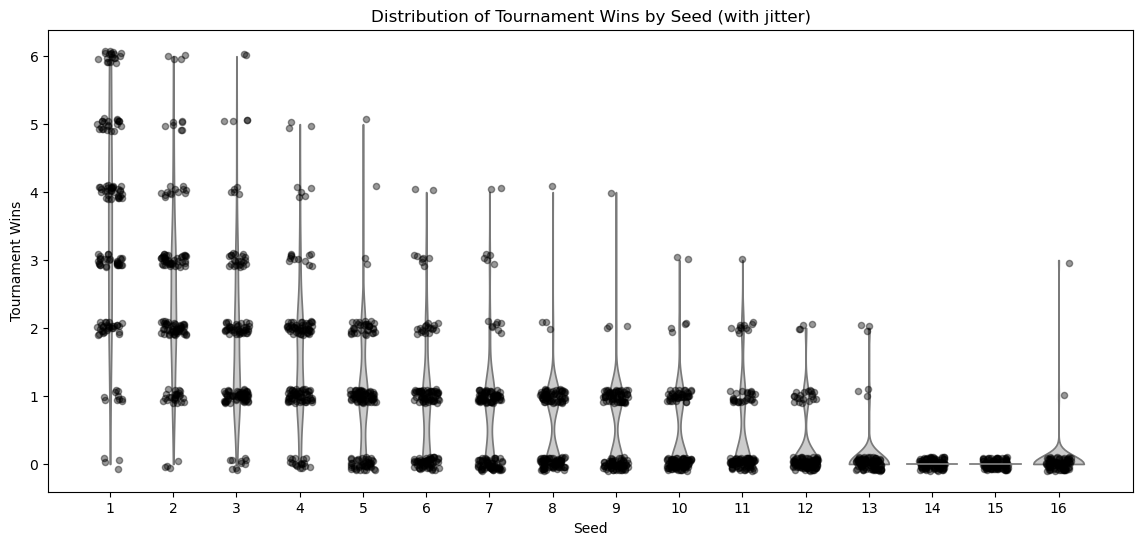

In [139]:
import numpy as np

plt.figure(figsize=(14, 6))

# Violin plot
sns.violinplot(data=marchmadness, x="seed", y="tourney_wins", inner=None, color="0.8", cut=0)

# Add custom jitter
x_vals = marchmadness["seed"].astype("category").cat.codes
y_vals = marchmadness["tourney_wins"]

# Jitter both x and y
x_jitter = x_vals + np.random.uniform(-0.2, 0.2, size=len(x_vals))
y_jitter = y_vals + np.random.uniform(-0.1, 0.1, size=len(y_vals))

plt.scatter(x_jitter, y_jitter, alpha=0.4, color="black", s=20)

plt.xticks(ticks=np.arange(len(marchmadness["seed"].unique())), 
           labels=sorted(marchmadness["seed"].unique()))
plt.xlabel("Seed")
plt.ylabel("Tournament Wins")
plt.title("Distribution of Tournament Wins by Seed (with jitter)")

plt.show()

In [123]:
import altair as alt

# Violin plot (horizontal orientation, grouped by seed)
violin = alt.Chart(marchmadness).transform_density(
    'tourney_wins',
    as_=['tourney_wins', 'density'],
    groupby=['seed']
).mark_area(orient='horizontal').encode(
    alt.X('density:Q')
        .stack('center')
        .impute(None)
        .title(None)
        .axis(labels=False, values=[0], grid=False, ticks=True),
    alt.Y('tourney_wins:Q'),
    alt.Column('seed:O')
        .spacing(0)
        .header(titleOrient='bottom', labelOrient='bottom', labelPadding=0)
        .title('Seed')
).configure_view(
    stroke=None
).properties(width=100)

# Jitter plot with offsets for scatter points
jitter_plot = alt.Chart(marchmadness).mark_circle(size=20, opacity=0.25).encode(
    x=alt.X('seed:N', title='Seed'),
    y=alt.Y('tourney_wins:Q', title='Tournament Wins'),
    xOffset=alt.XOffset('jitterx:Q'),
    yOffset=alt.YOffset('jittery:Q')
).transform_calculate(
    jitterx='(random() - 0.5)',  # uniform jitter [-0.5, 0.5]
    jittery='(random() - 0.5)'
).properties(
    title='Distribution of Tournament Wins by Seed'
)

# Because the violin plot is faceted by seed (columns), 
# you can't directly layer with a flat jitter plot.
# Instead, use horizontal concatenation to put them side by side.

combined_chart = alt.hconcat(
    violin,
    jitter_plot
).resolve_scale(
    y='shared'
)

combined_chart

TypeError: Objects with 'config' attribute cannot be used within HConcatChart. Consider defining the config attribute in the HConcatChart object instead.

In [126]:
violin = alt.Chart(marchmadness).transform_density(
    'tourney_wins',
    as_=['tourney_wins', 'density'],
    groupby=['seed']
).mark_area(orient='horizontal').encode(
    alt.X('density:Q')
        .stack('center')
        .impute(None)
        .title(None)
        .axis(labels=False, values=[0], grid=False, ticks=True),
    alt.Y('tourney_wins:Q'),
    alt.Column('seed:O')
        .spacing(0)
        .header(titleOrient='bottom', labelOrient='bottom', labelPadding=0)
        .title('Seed')
).configure_view(
    stroke=None
).properties(width=100)

jitter = alt.Chart(marchmadness).mark_circle(size=20, opacity=0.25).encode(
    y=alt.Y('tourney_wins:Q'),
    x=alt.X('jitterx:Q', title=None, axis=None),
    column=alt.Column('seed:O')
).transform_calculate(
    jitterx='(random() - 0.5)',
)

layered = alt.layer(violin, jitter).resolve_scale(
    y='shared'
)

layered


TypeError: Objects with 'config' attribute cannot be used within LayerChart. Consider defining the config attribute in the LayerChart object instead.

In [128]:
violin = alt.Chart(marchmadness).transform_density(
    'tourney_wins',
    as_=['tourney_wins', 'density'],
    groupby=['seed']
).mark_area(orient='horizontal').encode(
    alt.X('density:Q')
        .stack('center')
        .impute(None)
        .title(None)
        .axis(labels=False, values=[0], grid=False, ticks=True),
    alt.Y('tourney_wins:Q'),
    alt.Column('seed:O')
        .spacing(0)
        .header(titleOrient='bottom', labelOrient='bottom', labelPadding=0)
        .title('Seed')
)

jitter = alt.Chart(marchmadness).transform_calculate(
    jitterx='(random() - 0.5)',
    jittery='(random() - 0.5)'
).mark_circle(size=20, opacity=0.25).encode(
    y=alt.Y('tourney_wins:Q'),
    x=alt.X('jitterx:Q', title=None, axis=None),
    column=alt.Column('seed:O')
)

layered = alt.layer(violin, jitter).configure_view(stroke=None)

layered


TypeError: Faceted charts cannot be layered. Instead, layer the charts before faceting.

In [136]:
import altair as alt

base = alt.Chart(marchmadness).transform_calculate(
    jitterx='(random() - 0.5)',
    jittery='(random() - 0.5)'
).properties(
    width=100
)

violin = base.transform_density(
    'tourney_wins',
    as_=['tourney_wins', 'density'],
    groupby=['seed']
).mark_area(orient='horizontal').encode(
    alt.X('density:Q')
        .stack('center')
        .impute(None)
        .title(None)
        .axis(labels=False, values=[0], grid=False, ticks=True),
    alt.Y('tourney_wins:Q')
)

jitter = base.mark_circle(size=20, opacity=0.25).encode(
    y='tourney_wins:Q',
    x=alt.X('jitterx:Q', title=None, axis=None)
)

layered = alt.layer(violin, jitter)  # NO configure_view here

final_chart = layered.facet(
    column=alt.Column('seed:O', header=alt.Header(labelOrient='bottom', title='Seed'))
).configure_view(stroke=None)  # Apply config here, once

final_chart


alt.FacetChart(...)